# Bulk data reader (2026-03-03)

This notebook scans `data/bulk_downloads/`, summarizes file inventory, and computes basic stats for the main outputs.

## Imports and Definitions

In [4]:
import re
from blingfire import text_to_sentences
from pathlib import Path
from IPython.display import IFrame, display
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
import os
from openai import OpenAI
from IPython.display import HTML, display
import html
import warnings
warnings.simplefilter('ignore', category=SyntaxWarning)


def preprocess_text(text: str) -> str:
    if text is None:
        return ""
    text = str(text)
    text = text.replace("\n", " ")
    text = re.sub(r"\s+", " ", text)
    text = re.sub(r"PAGE\s*\d*", " ", text)
    text = re.sub(r"COMMENT\s*\d*", " ", text)
    text = text.replace("<", " ").replace(">", " ")
    text = re.sub(r"false\s*\d*", " ", text)
    text = re.sub(r"\s+", " ", text)
    return text.strip()

def clean_sentence(sent: str) -> str:
    sent = re.sub(r"PAGE \d", " ", sent)
    sent = re.sub(r"COMMENT \d", " ", sent)
    sent = sent.replace("<", " ").replace(">", " ")
    sent = re.sub(r"false\s*\d*", " ", sent)
    sent = re.sub(r"\s+", " ", sent)
    return sent.strip()

def bling_sentences(canonical_text: str) -> list[str]:
    text = preprocess_text(canonical_text)
    sents = text_to_sentences(text).strip().split("\n") if text else []
    sents = [clean_sentence(s) for s in sents]
    return [s for s in sents if s]  # drop empties

# reconstruct a chunk (inclusive indices)
def reconstruct_chunk(sentences: list[str], start_idx: int, end_idx: int) -> str:
    return " ".join(sentences[start_idx : end_idx + 1]).strip()

def download_and_show_pdf(url: str, *, filename: str | None = None, out_dir: str = "pdf_cache", width: int = 900, height: int = 700):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    if filename is None:
        filename = url.split("?")[0].split("/")[-1] or "attachment.pdf"
    pdf_path = out_dir / filename

    if not pdf_path.exists():
        try:
            from curl_cffi import requests as creq
            r = creq.get(
                url,
                impersonate="chrome110",
                headers={
                    "Referer": "https://www.regulations.gov/",
                    "Accept": "application/pdf,*/*",
                },
                allow_redirects=True,
                timeout=60,
            )
        except Exception:
            import requests
            r = requests.get(
                url,
                headers={
                    "User-Agent": "Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/121.0.0.0 Safari/537.36",
                    "Referer": "https://www.regulations.gov/",
                    "Accept": "application/pdf,*/*",
                },
                allow_redirects=True,
                stream=True,
                timeout=60,
            )

        if r.status_code != 200:
            print("status:", r.status_code)
            try:
                print("final url:", r.url)
            except Exception:
                pass
            try:
                print("history:", [h.status_code for h in r.history])
            except Exception:
                pass
            raise RuntimeError("Download failed")

        pdf_path.write_bytes(r.content)

    display(IFrame(src=f"{pdf_path.as_posix()}", width=width, height=height))
    return pdf_path
# Example:
# download_and_show_pdf("https://downloads.regulations.gov/FWS-R7-NWRS-2017-0058-32606/attachment_1.pdf")

PALETTE = [
    "#fef3c7",  # amber-100
    "#dbeafe",  # blue-100
    "#dcfce7",  # green-100
    "#fee2e2",  # red-100
    "#f3e8ff",  # purple-100
]

def render_chunks(chunks, *, show_index=True, show_meta=False):
    blocks = []
    for i, chunk in enumerate(chunks):
        text = html.escape(str(chunk.get("chunk_text", "").replace('$', '\$')) if isinstance(chunk, dict) else str(chunk))
        color = PALETTE[i % len(PALETTE)]
        header = ""
        if show_index:
            if isinstance(chunk, dict) and show_meta:
                meta = f"(idx={chunk.get('chunk_index')}, sent={chunk.get('sentence_start_index')}–{chunk.get('sentence_end_index')})"
            else:
                meta = f"(idx={i})"
            header = f"<div style='font-size:12px;color:#555;margin-bottom:4px;'>{meta}</div>"
        blocks.append(
            f"<div style='background:{color};padding:8px;margin:6px 0;border-radius:6px;line-height:1.4;'>"
            f"{header}{text}</div>"
        )
    html_block = "<div style='font-family:system-ui, sans-serif;'>" + "".join(blocks) + "</div>"
    display(HTML(html_block))

pd.set_option("display.max_columns", 200)
pd.set_option("display.max_rows", 200)

os.environ["OPENAI_API_KEY"] = open('/Users/spangher/.openai-salt-lab-key.txt').read().strip()
def prompt_openai(prompt, model="gpt-5-mini"):
    client = OpenAI()
    response = client.responses.create(
        model=model,
        input=prompt
    )
    return response.output_text

# Set up File Inventory

In [5]:
ROOT = Path("../data/bulk_downloads").resolve()
RUN_FULL_SCAN = False
MAX_FILES_PER_TYPE = 5
CHUNKSIZE = 100_000

files = [p for p in ROOT.rglob("*.csv") if p.is_file() and "downloaded_content" not in str(p)]

In [6]:
inventory = (
    pd.DataFrame({"path": [str(p) for p in files]})
    .assign(
        rel_path=lambda df: df["path"].str.replace(str(ROOT) + "/", "", regex=False),
        file_name=lambda df: df["path"].str.split("/").str[-1],
        agency=lambda df: df["rel_path"].str.split("/", n=2).str[0],
        period=lambda df: df["rel_path"].str.split("/", n=2).str[1],
    )
)

inventory = inventory.assign(file_type=lambda df:
    np.select(
        [
            df["file_name"].str.endswith("_all_text_chunked_llm_labels.csv"),
            df["file_name"].str.endswith("_all_text_chunked.csv"),
            df["file_name"].str.endswith("_all_text_response_matches.csv"),
            df["file_name"].str.endswith("_all_text_score_samples.csv"),
            df["file_name"].str.endswith("_all_text_comment_labels.csv"),
            df["file_name"].str.endswith("_all_text.csv"),
        ],
        [
            "llm_labels",
            "chunked",
            "response_matches",
            "score_samples",
            "comment_labels",
            "all_text",
        ],
        default="other",
    )
)

inventory.head()

,path,rel_path,file_name,agency,period,file_type
0,/Users/spangher/Projects/stanford-research/rfi...,scripts/content_download_errors.csv,content_download_errors.csv,scripts,content_download_errors.csv,other
1,/Users/spangher/Projects/stanford-research/rfi...,scripts/agency_list.csv,agency_list.csv,scripts,agency_list.csv,other
2,/Users/spangher/Projects/stanford-research/rfi...,scripts/pipeline_log.csv,pipeline_log.csv,scripts,pipeline_log.csv,other
3,/Users/spangher/Projects/stanford-research/rfi...,scripts/bulk_downloads_all_text.csv,bulk_downloads_all_text.csv,scripts,bulk_downloads_all_text.csv,all_text
4,/Users/spangher/Projects/stanford-research/rfi...,scripts/blank_results.csv,blank_results.csv,scripts,blank_results.csv,other


## Coverage and missing outputs

This section shows which datasets have chunked comments and matching outputs.
Use this to track periods like `*_2025_2026` that have raw data but no matches yet.


In [89]:
def _summarize_group(g):
    base = g['base_stem'].iloc[0]
    names = set(g['file_name'])
    return pd.Series({
        'has_all_text': f'{base}.csv' in names,
        'has_chunked': f'{base}_chunked.csv' in names,
        'has_llm_labels': f'{base}_chunked_llm_labels.csv' in names,
        'has_score_samples': f'{base}_score_samples.csv' in names,
        'has_response_matches': f'{base}_response_matches.csv' in names,
        'has_comment_labels': f'{base}_comment_labels.csv' in names,
    })

In [127]:
files_by_agency = (
    inventory
         .loc[lambda df: ~df['agency'].str.contains('.csv')]
         .loc[lambda df: ~df['file_name'].str.contains(r'_\d.csv')]
         .assign(filetype=lambda df: df['file_name'].str.replace('.csv', ''))
         .groupby(['agency', 'period'])['filetype'].aggregate(list)
         .apply(lambda x: pd.Series({y:1 for y in x})).fillna(0).astype(int)
)

### all agencies

In [521]:
agency_level_data = (
    files_by_agency
         .reset_index()[['agency', 'period']]
         .assign(years=lambda df: df['period'].str.split('_').apply(lambda x: x[1:]).str.join('-'))
         .loc[lambda df: df['years'].str.contains('-')]
         .assign(c=1)
         .pivot_table(index='agency', columns='years', values='c')
         .fillna(0).astype(int)
)

agency_level_data.style.format(lambda v: 'retrieved' if v == 1 else 'missing').map(lambda v: 'background-color: red; color: white' if v == 0 else 'background-color: white')

years,2016-2017,2017-2018,2018-2019,2019-2020,2020-2021,2021-2022,2022-2023,2023-2024,2024-2025,2025-2026,2026-2027
agency,,,,,,,,,,,
ams,missing,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved
aphis,missing,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved
cdc,missing,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,missing,missing,missing
cms,missing,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved
dhs,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved
doe,missing,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved
doj,missing,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved
epa,missing,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved
faa,missing,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,retrieved,missing,missing,missing


In [524]:
worksheet = sh.get_worksheet(2)
df_to_upload = agency_level_data.replace({0: 'missing', 1: 'retrieved'}).reset_index()
set_with_dataframe(worksheet, df_to_upload)
format_with_dataframe(worksheet, df_to_upload, formatter, include_column_header=True)
rule = ConditionalFormatRule(
    ranges=[GridRange.from_a1_range('A1:Z100', worksheet)], # Adjust range as needed
    booleanRule=BooleanRule(
        condition=BooleanCondition('TEXT_EQ', ['missing']),
        format=red_style
    )
)
rules = get_conditional_format_rules(worksheet)
rules.append(rule)
rules.save()

{'spreadsheetId': '1PQJ6dj5bTFGeoLLPsKVnaY8fkLskO_G2TQbYKwMpt3E',
 'replies': [{'deleteConditionalFormatRule': {'rule': {'ranges': [{'sheetId': 2048229143,
       'startRowIndex': 0,
       'endRowIndex': 100,
       'startColumnIndex': 0,
       'endColumnIndex': 26}],
     'booleanRule': {'condition': {'type': 'TEXT_EQ',
       'values': [{'userEnteredValue': 'missing'}]},
      'format': {'backgroundColor': {'red': 1},
       'textFormat': {'foregroundColor': {'red': 1, 'green': 1, 'blue': 1},
        'foregroundColorStyle': {'rgbColor': {'red': 1,
          'green': 1,
          'blue': 1}}},
       'backgroundColorStyle': {'rgbColor': {'red': 1}}}}}}},
  {},
  {}]}

### Files that we are missing PDF downloads/parsing for:

In [173]:
from more_itertools import flatten
original_download_files = [
    ('notice', 'notice_all_text'),
    ('rules','rules_all_text'),
    ('proposed_rules', 'proposed_rules_all_text'),
    ('public_submission', 'public_submission_all_text')
]

In [197]:
missing_file_map = []
for o in original_download_files:
    f_init = files_by_agency[o[0]].loc[lambda s: s == 0]
    missing_file_map.append(f_init.to_frame(o[0]))
    f = files_by_agency[o[1]].loc[lambda s: s == 0]
    missing_file_map.append(f.to_frame(o[1]))

In [ ]:
import pyperclip
import pandas as pd
import gspread
from gspread_dataframe import set_with_dataframe
import gspread
from gspread_dataframe import set_with_dataframe
from gspread_formatting import Color
from gspread_formatting.dataframe import format_with_dataframe, BasicFormatter
from gspread_formatting import *

# Authenticate using the service account file
gc = gspread.oauth(credentials_filename='/Users/spangher/.google-cloud/usc-research-data-access-new.json')

In [483]:
all_missing_top_level_file_map = pd.concat(missing_file_map, axis=1)

(all_missing_top_level_file_map
 .style.format(lambda v: 'missing' if v == 0 else 'finished')
 .map(lambda v: 'background-color: red; color: white' if v == 0 else 'background-color: white')
)

In [ ]:
sh = gc.open("test spreadsheet")
worksheet = sh.get_worksheet(0)

# upload to google sheets
df_to_upload = all_missing_top_level_file_map.replace({0: 'missing'}).fillna('retrieved').reset_index()

worksheet = sh.get_worksheet(1)
set_with_dataframe(worksheet, df_to_upload.loc[:, lambda df: list(filter(lambda x: 'all_text' not in x, df.columns))])

formatter = BasicFormatter(
    header_background_color=Color(0.2, 0.2, 0.2), # Dark grey header
    header_text_color=Color(1, 1, 1),             # White text
    decimal_format='#,##0.00'                     # Standard number format
)

format_with_dataframe(worksheet, df_to_upload, formatter, include_column_header=True)

# Define the red background and white text style
red_style = CellFormat(
    backgroundColor=Color(1, 0, 0), # Red
    textFormat=TextFormat(foregroundColor=Color(1, 1, 1)) # White
)

# Create a rule: if text is "missing", apply red style
rule = ConditionalFormatRule(
    ranges=[GridRange.from_a1_range(f'A1:Z{len(df_to_upload) + 1}', worksheet)], # Adjust range as needed
    booleanRule=BooleanRule(
        condition=BooleanCondition('TEXT_EQ', ['missing']),
        format=red_style
    )
)

# Save the rules to the worksheet
rules = get_conditional_format_rules(worksheet)
rules.append(rule)
rules.save()


def merge_vertical_duplicates(ws, df, col_idx=1):
    # Get the column values (e.g., 'agency')
    values = df.iloc[:, col_idx-1].tolist()
    
    # 1. Clear existing merges in Column A to prevent "overlap" errors
    # Adjust range (e.g., A1:A1000) as needed
    ws.unmerge_cells(f"A1:A{len(values) + 1}")
    
    start_idx = 0
    while start_idx < len(values):
        current_val = values[start_idx]
        end_idx = start_idx
        
        # Find how far this value repeats
        while end_idx < len(values) and values[end_idx] == current_val:
            end_idx += 1
        
        # If it repeats (more than 1 occurrence)
        if end_idx - start_idx > 1:
            # Sheets is 1-indexed + 1 for header = start_idx + 2
            row_start = start_idx + 2
            row_end = end_idx + 1 # end_idx is exclusive in Python, inclusive in A1
            
            try:
                ws.merge_cells(f"A{row_start}:A{row_end}", "MERGE_ALL")
            except Exception as e:
                print(f"Skipping merge for {current_val} at A{row_start}:A{row_end}: {e}")
        
        start_idx = end_idx


# Execute merge for the first column ('agency')
merge_vertical_duplicates(worksheet, df_to_upload, col_idx=1)

# Optional: Center the text vertically/horizontally
format_cell_range(worksheet, "A:A", CellFormat(
    verticalAlignment='MIDDLE', 
    horizontalAlignment='CENTER'
))

In [ ]:
public_sub_cols = [
    'public_submission_all_text', 
    'public_submission_all_text_chunked',
    'public_submission_all_text_comment_labels',
    'public_submission_all_text_response_matches',
    'public_submission_all_text_chunked_llm_labels',
    'public_submission_all_text_score_samples',
]

columns_we_care_about = [
    'public_submission_all_text_chunked',
    'public_submission_all_text_response_matches',
    'public_submission_all_text_score_samples'
]

In [202]:
public_comment_missing_file_map = []
for c in columns_we_care_about:
    f = files_by_agency.loc[lambda df: df['public_submission_all_text'] == 1][c].loc[lambda s: s == 0]
    public_comment_missing_file_map.append(f.to_frame(c))

In [203]:
all_public_comment_missing_file_map = pd.concat(public_comment_missing_file_map, axis=1)

In [207]:
(
    all_public_comment_missing_file_map
     .reset_index()
     .loc[lambda df: df['period'].str.split('_').str.get(1).astype(int) < 2024 ]
     .set_index(['agency', 'period']).sort_index()
     .style.format(lambda v: 'missing' if v == 0 else 'finished')
     .map(lambda v: 'background-color: red; color: white' if v == 0 else 'background-color: white')
)

In [514]:
df_to_upload_2 = all_public_comment_missing_file_map.replace({0: 'missing'}).fillna('finished').reset_index()

In [517]:
worksheet = sh.get_worksheet(1)
set_with_dataframe(worksheet, df_to_upload_2)

In [518]:
format_with_dataframe(worksheet, df_to_upload_2, formatter, include_column_header=True)

{'spreadsheetId': '1PQJ6dj5bTFGeoLLPsKVnaY8fkLskO_G2TQbYKwMpt3E',
 'replies': [{}, {}, {}, {}, {}, {}]}

In [520]:
# Save the rules to the worksheet
# Create a rule: if text is "missing", apply red style
rule = ConditionalFormatRule(
    ranges=[GridRange.from_a1_range('A1:Z100', worksheet)], # Adjust range as needed
    booleanRule=BooleanRule(
        condition=BooleanCondition('TEXT_EQ', ['missing']),
        format=red_style
    )
)

# Save the rules to the worksheet
rules = get_conditional_format_rules(worksheet)
rules.append(rule)
rules.save()


{'spreadsheetId': '1PQJ6dj5bTFGeoLLPsKVnaY8fkLskO_G2TQbYKwMpt3E',
 'replies': [{}]}

In [558]:
to_upload_dir = inventory.loc[lambda df: df['file_name'].str.contains('_all_text.csv')].loc[lambda df: ~df['agency'].str.contains('.csv')]

In [557]:
mkdir ../data/bulk_downloads/to_upload

In [574]:
import shutil

In [578]:
to_upload_path = "../data/bulk_downloads/to_upload"
for _, row in tqdm(to_upload_dir.iterrows(), total=len(to_upload_dir)):
    dest_path = (Path(to_upload_path) / row['rel_path'])
    dest_path.parent.mkdir(exist_ok=True, parents=True)
    shutil.copy(row['path'], dest_path)

  0%|          | 0/937 [00:00<?, ?it/s]

# All Text PDF

## Determine optimal comment splitting approach

### analysis

In [7]:
from tqdm.notebook import tqdm

In [8]:
all_text_paths = inventory.loc[lambda df: df['file_name'].str.contains('public_submission_all_text.csv')]['path'].tolist()

In [9]:
all_titles= []
for path in tqdm(all_text_paths):
    titles = pd.read_csv(path, usecols=['Title'])['Title']
    all_titles += titles.tolist()
all_titles = pd.Series(all_titles)

  0%|          | 0/213 [00:00<?, ?it/s]

In [10]:
attachments_per_file = []
for path in tqdm(all_text_paths):
    sample_all_text_df = pd.read_csv(path, usecols=['Title', 'Agency ID', 'Docket ID', 'Document ID', 'Posted Date', 'Comment', 'Attachment Files', 'canonical_text'])
    sample_all_text_df['num_attachments'] = sample_all_text_df['Attachment Files'].fillna('').str.split(',').str.len()
    attachments_per_file.append(sample_all_text_df)

  0%|          | 0/213 [00:00<?, ?it/s]

/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_92150/2817635637.py:3: DtypeWarning: Columns (58) have mixed types. Specify dtype option on import or set low_memory=False.
  sample_all_text_df = pd.read_csv(path, usecols=['Title', 'Agency ID', 'Docket ID', 'Document ID', 'Posted Date', 'Comment', 'Attachment Files', 'canonical_text'])
/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_92150/2817635637.py:3: DtypeWarning: Columns (58) have mixed types. Specify dtype option on import or set low_memory=False.
  sample_all_text_df = pd.read_csv(path, usecols=['Title', 'Agency ID', 'Docket ID', 'Document ID', 'Posted Date', 'Comment', 'Attachment Files', 'canonical_text'])
/var/folders/xh/qnyq7yzj0r328_7hnb7pgxth0000gp/T/ipykernel_92150/2817635637.py:3: DtypeWarning: Columns (58) have mixed types. Specify dtype option on import or set low_memory=False.
  sample_all_text_df = pd.read_csv(path, usecols=['Title', 'Agency ID', 'Docket ID', 'Document ID', 'Posted Date', 'Comme

In [11]:
all_attachments_df = pd.concat(attachments_per_file)

In [12]:
def dedup_urls(url_string):
    urls = [u.strip() for u in url_string.split(',') if u.strip()]
    groups = {}
    for url in urls:
        base = url.rsplit('.', 1)[0]
        groups.setdefault(base, []).append(url)
    return [
        next((u for u in variants if u.endswith('.pdf')), variants[0])
        for variants in groups.values()
    ]

In [13]:
tqdm.pandas()
all_attachments_df['Attachment Files'] = all_attachments_df['Attachment Files'].fillna('').progress_apply(dedup_urls)
all_attachments_df['num_attachments'] = all_attachments_df['Attachment Files'].str.len()
all_attachments_df['num_pages'] = all_attachments_df['canonical_text'].str.split('<<PAGE').str.len()

  0%|          | 0/6266463 [00:00<?, ?it/s]

In [14]:
all_attachments_df

,Document ID,Agency ID,Docket ID,Posted Date,Title,Comment,Attachment Files,canonical_text,num_attachments,num_pages
0,MSHA-2014-0019-0131,MSHA,MSHA-2014-0019,2017-02-17T05:00Z,"Comment from anonymous anonymous, NA",RIN 1219-AB78\n\nI support this rule. If it ha...,[],<<COMMENT 1>>\nfalse\n\n0\n\nRIN 1219-AB78\n\n...,0,1
1,MSHA-2014-0019-0132,MSHA,MSHA-2014-0019,2017-02-17T05:00Z,"David Hales, Safety Manager, San Juan Coal Com...",See Attached,[https://downloads.regulations.gov/MSHA-2014-0...,<<COMMENT 1>>\nfalse\n\n0\n\nSee Attached\n\n<...,1,12
2,MSHA-2014-0019-0133,MSHA,MSHA-2014-0019,2017-02-17T05:00Z,"Attachment from David Hales, U.S. Department o...",See Attached,[https://downloads.regulations.gov/MSHA-2014-0...,<<COMMENT 1>>\nfalse\n\n0\n\nSee Attached\n\n<...,1,2
3,MSHA-2014-0019-0134,MSHA,MSHA-2014-0019,2017-02-28T05:00Z,"Comment from Anonymous Anonymous, NA",I do believe that all miners working under the...,[],<<COMMENT 1>>\nfalse\n\n0\n\nI do believe that...,0,1
4,MSHA-2014-0019-0135,MSHA,MSHA-2014-0019,2017-03-08T05:00Z,"Comment from Daniel Kassab, NA",I believe that this regulation is very smart. ...,[],<<COMMENT 1>>\nfalse\n\n0\n\nI believe that th...,0,1
...,...,...,...,...,...,...,...,...,...,...
24461,FS-2020-0007-3871,FS,FS-2020-0007,2020-11-03T05:00Z,Comment on FR Doc # 2020-18518,I strongly oppose selling out the legacy of ou...,[],<<COMMENT 1>>\nfalse\n\nI strongly oppose sell...,0,1
24462,FS-2020-0007-3872,FS,FS-2020-0007,2020-11-03T05:00Z,Comment on FR Doc # 2020-18518,See attached file(s),[https://downloads.regulations.gov/FS-2020-000...,<<COMMENT 1>>\nfalse\n\nSee attached file(s)\n...,1,3
24463,FS-2020-0007-3873,FS,FS-2020-0007,2020-11-03T05:00Z,Comment on FR Doc # 2020-18518,See attached file(s),[https://downloads.regulations.gov/FS-2020-000...,<<COMMENT 1>>\nfalse\n\nSee attached file(s)\n...,1,6
24464,FS-2020-0007-3874,FS,FS-2020-0007,2020-11-03T05:00Z,Comment on FR Doc # 2020-18518,See attached file(s),[https://downloads.regulations.gov/FS-2020-000...,<<COMMENT 1>>\nfalse\n\nSee attached file(s)\n...,1,3


In [ ]:
all_attachments_long_comments = all_attachments_df.loc[lambda df: df['num_pages'] > 2].sort_values('num_pages', ascending=False)

In [ ]:
# file comment_classifier.py is from Claude and is a set of heuristcs to identify comment campaigns based on common patterns

In [ ]:
from importlib import reload
import comment_classifier
import comment_classifier_2
reload(comment_classifier)
reload(comment_classifier_2)

In [ ]:
heuristic_classifications = (
    all_attachments_long_comments
        .progress_apply(lambda x: comment_classifier_2.classify_comment(x['canonical_text'], x['Title']), axis=1)
)

In [ ]:
# 
# Parse comments with regexes
# Develop a database of comments — individual comments grouped by the groupers the government uses for campaigns, and single comments 
#     for non-campaigns.
# Audit the government's grouping mechansim? Try to develop my own grouping? 
# Extract core claims made by each comment.
# Match gov response <-> comment ? 
# Match gov response <-> comment claim? 
# 

In [ ]:
classification_heuristics_df = pd.DataFrame(heuristic_classifications.tolist())

In [875]:
classification_heuristics_df['classification'].value_counts()

classification
definitely_single              227531
definitely_campaign              7598
uncertain                        1198
references_other_submission       704
Name: count, dtype: int64

In [ ]:
all_attachments_long_comments_w_cls = pd.concat([
    all_attachments_long_comments.reset_index(drop=True),
    classification_heuristics_df    
], axis=1)

all_attachments_long_comments_w_cls.to_csv('2026-03-04__comments-with-campaigns-text.csv.gz', compression='gzip')

In [ ]:
# comment titles that signify mass campaings (do we trust these?)
# long comments
# comments with 

In [ ]:
prompt_format = """Here is the body of a PDF that I parsed from regulations.gov. It represents a comment, or comments, submitted in response 
to a proposed rule. 

It either represents a single comment or a group of comments that have been pasted together and I am trying to determine which one it is.

Answer with "single"/"group". Only answer this, nothing else.

<parsed_pdf>
{comment}
</parsed_pdf>
"""

In [ ]:
import prompt_utils

sample_df = all_attachments_long_comments_w_cls.groupby('classification').apply(lambda df: df.sample(50))
ps = sample_df.apply(lambda x: prompt_format.format(comment=x['canonical_text'][:20_000].replace('<<COMMENT', '<<PART')), axis=1)
answers = await prompt_utils.process_batch(prompts=ps.tolist(), model='gpt-5', )

In [ ]:
sample_df['llm_answers' ] = answers

In [ ]:
(sample_df
     .reset_index(drop=True)
     [['classification', 'llm_answers']]
     .groupby('classification')['llm_answers']
     .value_counts()
     .unstack()
)

In [884]:
(sample_df
 .loc[lambda df: 
     ((df['classification'] == 'definitely_campaign') & (df['llm_answers'] == 'single'))
     # | ((df['classification'] == 'definitely_single') & (df['llm_answers'] == 'group'))
 ]
 [['Title', 'canonical_text', 'classification', 'llm_answers', 'reasons']]
 .reset_index(drop=True)
 .to_csv('2026-03-04__error-cases.csv')
 # .loc[3, 'reasons']
 # .loc[3]['canonical_text']
)

In [834]:
uncertain_sample = all_attachments_long_comments_w_cls.loc[lambda df: df['classification'] == 'uncertain'].sample(200)
ps = uncertain_sample.apply(lambda x: prompt_format.format(comment=x['canonical_text'][:20_000].replace('<<COMMENT', '<<PART')), axis=1)

In [835]:
answers = await prompt_utils.process_batch(prompts=ps.tolist(), model='gpt-5', )

  0%|          | 0/200 [00:00<?, ?it/s]

In [836]:
uncertain_sample['llm_answers'] = answers

In [838]:
uncertain_sample['llm_answers'].value_counts()

llm_answers
single    192
group       8
Name: count, dtype: int64

In [839]:
(
    uncertain_sample
         .pipe(lambda df: pd.concat([
             df.loc[lambda df: df['llm_answers'] == 'group'],
             df.loc[lambda df: df['llm_answers'] == 'single'].sample(8),
         ]))
         .sample(frac=1)
         [['Title', 'canonical_text', 'classification', 'llm_answers', 'reasons']]
         .reset_index(drop=True)
         .to_csv('2026-03-04__uncertain-cases.csv')
)

### Automatic chunking detection

In [ ]:
import re

In [ ]:
possible_campaigns = (
    all_attachments_long_comments_w_cls
        .loc[lambda df: df['classification'].isin(['definitely_campaign', 'uncertain'])]
)

In [ ]:
campaigns_to_parse = possible_campaigns['canonical_text'].str.replace('<<COMMENT', '<<PART')
c = campaigns_to_parse.iloc[0]

In [1018]:
regex_prompt = """Here is the body of a PDF that I parsed from regulations.gov. I think it represents
a group of comments submitted in response to a proposed rule. 

Please output a regex to help me identify the boundary between comments in this group, so I can parse this into individual comments. 
Ignore <<PART \d+>> or <<PAGE \d+>> markers, those were markers I injected and do not factor into the actual comment boundary 
I am trying to detect. Detect if multiple comments are present by looking for signatures, headers and other obvious markers. 
Also look for obvious repetitions of content, independent of headers, and anything that might indicate a new comment is starting.
 
Return a WELL-FORMED, VALID regex to identify the boundary, and nothing else. Your regex must be able to be used by python's re package and must work.
If I am incorrect and this group actually just represents a single comment, please return "single: <justification>" 

<parsed_pdf>
{comment}
</parsed_pdf>
"""

In [1019]:
regex_ps = possible_campaigns['canonical_text'].str.replace('<<COMMENT', '<<PART').apply(lambda x: regex_prompt.format(comment=x[:10_000]))

In [1021]:
candidate_regexes = await prompt_utils.process_batch(prompts=regex_ps, model='gpt-5')

  0%|          | 0/8796 [00:00<?, ?it/s]

In [1022]:
campaigns_to_parse_w_regex = campaigns_to_parse.to_frame().assign(regex=candidate_regexes)

In [1023]:
sub_campaigns_to_parse_w_regex = campaigns_to_parse_w_regex.loc[lambda df: df['regex'].str.startswith('single')]
regex_sub_ps = sub_campaigns_to_parse_w_regex['canonical_text'].apply(lambda x: regex_prompt.format(comment=x[:20_000]))
sub_candidate_regexes = await prompt_utils.process_batch(prompts=regex_sub_ps, model='gpt-5')

  0%|          | 0/5299 [00:00<?, ?it/s]

In [1024]:
campaigns_to_parse_w_regex = (
    pd.concat([
        campaigns_to_parse_w_regex, 
        sub_campaigns_to_parse_w_regex.assign(regex2=sub_candidate_regexes)[['regex2']]
    ], axis=1)
    .assign(regex=lambda df: df.apply(lambda x: x['regex2'] if pd.notnull(x['regex2']) else x['regex'] , axis=1))
    .drop(columns='regex2')
)

In [1025]:
possible_campaigns['regex'] = campaigns_to_parse_w_regex['regex']

In [ ]:
import regex
import re2

In [ ]:
def get_regex_chunks(text, pattern, chunk_size=10000, overlap=5000, verbose=False):
    if not isinstance(text, str) or not text:
        return []

    # Calculate start indices with overlap
    step = chunk_size - overlap
    indices = range(0, len(text), step)
    
    if verbose:
        indices = tqdm(indices, desc="Processing text chunks", leave=False)

    all_segments = []
    for start in indices:
        chunk = text[start : start + chunk_size]
        try:
            # re2.split returns a list of strings
            all_segments.extend(regex.split(pattern, chunk))
        except Exception as e:
            raise e # Trigger your LLM fixing logic outside

    return all_segments


import signal
import re

def timeout_handler(signum, frame):
    raise TimeoutError("Regex took too long!")

# Set the timeout limit
TIMEOUT_SECONDS = 10

chunked_campaigns = []
for _, row in tqdm(possible_campaigns.iterrows(), total=len(possible_campaigns)):
    if row['regex'].startswith('single') or pd.isna(row['canonical_text']):
        chunked_campaigns.append(np.nan)
        continue

    r = row['regex']
    success = False
    
    for i in range(2):
        # Register the signal
        signal.signal(signal.SIGALRM, timeout_handler)
        signal.alarm(TIMEOUT_SECONDS)
        
        try:
            # Process using your chunking function
            comment_chunks = get_regex_chunks(row['canonical_text'], r)
            chunked_campaigns.append(comment_chunks)
            signal.alarm(0)  # Cancel the alarm if successful
            success = True
            break
        except (TimeoutError, Exception) as e:
            signal.alarm(0) # Cancel alarm
            print(f"Iter {i}: {'Timeout' if isinstance(e, TimeoutError) else 'Error'}. Refactoring...")
            
            # Refined prompt for efficiency
            p = f"""The following regex is causing catastrophic backtracking/performance issues: {r}
            Rewrite it to be more efficient and performant while achieving the same goal.
            1. Remove nested quantifiers (e.g., (a+)+).
            2. Eliminate overlapping character classes.
            3. Use atomic groups if possible.
            4. Ensure it works without lookaheads if possible.
            Return ONLY the corrected regex string."""
            
            r = prompt_utils.process_one(prompt=p)
            
    if not success:
        chunked_campaigns.append(np.nan)


In [1050]:
pd.Series(chunked_campaigns).isnull().value_counts()

True     5151
False    3645
Name: count, dtype: int64

In [1054]:
possible_campaigns['regex'].str.startswith('single').value_counts()

regex
True     5146
False    3650
Name: count, dtype: int64

In [1055]:
possible_campaigns['chunked_campaigns'] = chunked_campaigns

In [1059]:
possible_campaigns.loc[lambda df: ~df['regex'].str.startswith('single')]['Agency ID'].value_counts()

Agency ID
CMS      1587
EPA       979
FDA       532
FWS       227
APHIS      94
ICEB       40
AMS        39
FS         39
USCIS      23
NHTSA      22
FAA        20
CDC        12
OSHA       10
FEMA        7
DOE         5
FSIS        5
USDA        3
NIST        3
DHS         2
DOJ         1
Name: count, dtype: int64

In [ ]:
(possible_campaigns
 .loc[lambda df: df['chunked_campaigns'].notnull()]
)

# Test comment claim extraction

In [1071]:
t = all_attachments_long_comments_w_cls.loc[lambda df: df['classification'] == 'definitely_single']['canonical_text'] 

In [1073]:
t = t.str.replace('<<COMMENT', '<<PART')

In [1075]:
prompt = """I will show you a comment made by a member of the public to a government agency. 
Extract all distinct claims and substantive arguments made by the commenter in their comment. 
Return as a python list. Don't return anything else. 
Here is the comment: 

<comment>
{comment}
</comment> 

Your response:"""

In [1077]:
resp = prompt_utils.process_one(prompt=prompt.format(comment=t.iloc[0][:100_000]))

In [1080]:
import json
json.loads(resp)

["Friends of the Earth (FOE) opposes Bayer/Monsanto's petition to determine nonregulated status for maize engineered for tolerance to dicamba, glufosinate, quizalofop, 2,4‑D, and tissue‑specific glyphosate and urges USDA to reject the petition.",
 'The GE maize would have negative, potentially dramatic or catastrophic, implications for agroecosystems, people, and the planet.',
 'Applications of new mixtures of these herbicides could undermine plant health, including harm to food crops and plant pest health.',
 'The GE maize would threaten human health and environmental health.',
 'The GE maize would accelerate the development of weed resistance.',
 'If deregulated, farmers may plant the GE seed defensively to avoid damage from chemical trespass even if they do not intend to use one or more of the herbicides.',
 'Residual herbicides in soil can be inadvertently re‑activated (for example when adding phosphate fertilizer) when farmers change rotations, such as adding a small grain or alfa

### check title indicators

In [1064]:
title_prompt = """I am studying mass comment campaigns, or comment campaigns on regulations.gov where many commenters 
say substantively the same thing, over and over again. I am looking at these titles applied by agencies. 
Does it reflect a mass comment campaign? Answer with "yes", "no" or "unclear". Do not say anything else.

{title}
"""

ps = all_attachments_long_comments_w_cls['Title'].apply(lambda x: title_prompt.format(title=x))

In [1063]:
ps.apply(enc.encode).str.len().sum()

13979348

In [1066]:
title_campaign_indicators = await prompt_utils.process_batch(prompts=ps.sample(500))

  0%|          | 0/500 [00:00<?, ?it/s]

In [ ]:
# todo for tomorrow:
# 1. expand chunked comments
# 2. run simple LHS hashing algorithm to detect comment campaigns. See how many the gov. already identified.
# 3. see if you can run de-duped comments through an LLM to extract claims. How long will this take? 
# [4. map claims to original comment] 
# 5. match claims to government responses

# 6. if there is time, then work on the articulability gap project.
# -> set up the rubric-generation pipeline on the cluster
# -> see if you can get it to run, save the rubrics, run them in LLM-as-a-judge
# -> 

In [1001]:
corrected_regex = prompt_utils.process_one(prompt=p)

In [1014]:
# re.split(corrected_regex, row['canonical_text'])

In [921]:
t = campaigns_to_parse_w_regex.loc[lambda df: df['regex'] != 'single']

In [926]:
c, r = t.iloc[-2]

In [932]:
s = campaigns_to_parse_w_regex.loc[lambda df: df['regex'] == 'single']

In [939]:
s1 = s.iloc[0]['canonical_text']

In [960]:
p = regex_prompt.format(comment=s1[:200_000])

In [961]:
prompt_utils.process_one(prompt=p, model='gpt-5')

'single: Single cover letter from Eckert Seamans (on behalf of JRC) submitting enclosed records to the docket, followed by FOIA-produced materials (e.g., “CDRH_Production_5-000xxx”) and internal emails; no repeated salutations, signature blocks, or distinct comment headers indicating multiple separate comments.'

In [905]:
split_parts = re.split(candidate_regex, campaigns_to_parse.iloc[idx])

# Identify Comment campaigns

In [911]:
mv ~/Downloads/comment_dedup.py . 

In [472]:
attachment_count = []
for path in tqdm(all_text_paths):
    sample_all_text_df = pd.read_csv(path)
    num_pages = sample_all_text_df['canonical_text'].str.split('<<PAGE').str.len().pipe(lambda s: s - 1).sum()
    num_attachments = sample_all_text_df['Attachment Files'].fillna('').str.split(',').explode().shape[0]
    attachment_count.append({
        'path': path,
        'num_words_total': sample_all_text_df['canonical_text'].str.split().str.len().sum(),
        'num_pages': num_pages,
        'num_attachments': num_attachments
    })

  0%|          | 0/213 [00:00<?, ?it/s]

In [475]:
attachment_count_df = pd.DataFrame(attachment_count)

In [476]:
attachment_count_df

,path,num_words_total,num_pages,num_attachments
0,/Users/spangher/Projects/stanford-research/rfi...,132558,265,212
1,/Users/spangher/Projects/stanford-research/rfi...,503,0,7
2,/Users/spangher/Projects/stanford-research/rfi...,83706,278,51
3,/Users/spangher/Projects/stanford-research/rfi...,569713,1471,196
4,/Users/spangher/Projects/stanford-research/rfi...,8845,26,7
...,...,...,...,...
208,/Users/spangher/Projects/stanford-research/rfi...,16020804,3587,68060
209,/Users/spangher/Projects/stanford-research/rfi...,13897,0,246
210,/Users/spangher/Projects/stanford-research/rfi...,27311976,2610,107589
211,/Users/spangher/Projects/stanford-research/rfi...,28205549,8661,97000


In [478]:
attachment_count_df['num_words_total'].sum()

2724074053

In [461]:
p = attachment_count_df.loc[208]['path']

In [463]:
t_df = pd.read_csv(p)

In [469]:
# t_df.loc[lambda df: df['Attachment Files'].notnull()]['canonical_text'].iloc[2]

In [471]:
attachment_count_df['num_attachments'].sum()

6493226

## Chunked comments (`*_all_text_chunked.csv`)

Stats and a sample length distribution.


In [213]:
from tqdm.notebook import tqdm

In [ ]:
chunked_paths = inventory.loc[lambda df: df["file_name"].str.contains("_all_text_chunked.csv"), "path"].tolist()

chunk_stats = []
for path in tqdm(chunked_paths):
    total_rows = 0
    total_chars = 0
    total_sentences = 0
    max_len = 0
    min_len = None
    doc_ids = set()

    for chunk in pd.read_csv(path, usecols=["document_id", "num_sentences", "chunk_text"], chunksize=CHUNKSIZE):
        chunk = chunk.fillna({"chunk_text": ""})
        total_rows += len(chunk)
        lengths = chunk["chunk_text"].str.len()
        total_chars += lengths.sum()
        total_sentences += chunk["num_sentences"].fillna(0).sum()
        max_len = max(max_len, int(lengths.max())) if len(lengths) else max_len
        min_len = int(lengths.min()) if min_len is None and len(lengths) else min_len
        if len(lengths) and min_len is not None:
            min_len = min(min_len, int(lengths.min()))
        doc_ids.update(chunk["document_id"].astype(str).unique().tolist())

    chunk_stats.append({
        "path": path,
        "rows": total_rows,
        "unique_documents": len(doc_ids),
        "avg_chunk_len": (total_chars / total_rows) if total_rows else 0,
        "avg_num_sentences": (total_sentences / total_rows) if total_rows else 0,
        "min_chunk_len": min_len if min_len is not None else 0,
        "max_chunk_len": max_len,
    })

In [375]:
# number of chunks per comment document, in one agency/year 
t_df = pd.read_csv(path)
t_df['document_id'].value_counts().value_counts().sort_index().head(10)

count
1      1324
2      5553
3     16111
4      1214
5       173
6        29
7         8
8         6
9         4
10        4
Name: count, dtype: int64

In [376]:
### let's look at the kinds of chunks we extract
### example one document

In [218]:
chunk_stat_df = pd.DataFrame(chunk_stats).sort_values("rows", ascending=False)

In [328]:
idx = 7
chunk_df_sample = pd.read_csv(chunk_stat_df.iloc[idx]['path'])
orig_all_text = pd.read_csv(chunk_stat_df.iloc[idx]['path'].replace('_chunked', ''))

In [340]:
sample_document_id = chunk_df_sample['document_id'].value_counts().loc[lambda s: s < 100].index[1]
sample_chunked_doc = chunk_df_sample.loc[lambda df: df['document_id'] == sample_document_id]
sample_full_doc = orig_all_text.loc[lambda df: df['Document ID'] == sample_document_id]
canonical_text = sample_full_doc['canonical_text'].iloc[0]

In [341]:
## check that the chunking preserves all chunks
sentences = bling_sentences(canonical_text)
full_joined_comment = ' '.join(list(map(lambda x: x.strip(), sentences)))
parsed_joined_comment = ' '.join(sample_chunked_doc['chunk_text'].tolist())
full_joined_comment == parsed_joined_comment

True

In [342]:
render_chunks(sample_chunked_doc.to_dict(orient='records'))

In [ ]:
attachment_files = sample_full_doc['Attachment Files'].iloc[0].split(',')
attachment_files

In [419]:
attachment_files

['https://downloads.regulations.gov/EPA-HQ-OPP-2013-0266-1026/attachment_1.pdf']

In [581]:
! rm pdf_cache/*
download_and_show_pdf(attachment_files[0])
# download_and_show_pdf(t)

PosixPath('pdf_cache/attachment_1.pdf')

In [ ]:
prompt = f"I will show you a document that I believe contains lots of ",
prompt_openai()

In [537]:
## tasks:
## -----------------------
## 1. For the agencies that we're missing certain primary documents for: notice, rules, proposed rules, public submission, check on gemini/claude/chatGPT why we are missing them. Many do not post comments/notices. Others do.
## 2. For the agencies we're missing downstream files for, which are primarily comment-matching files, I am checking this right now. I'm currently blocked by #3:
## 3. I/we need to continue to spend some cycles on comment-chunking....
## 4. I also suspect that comment matching is particularly difficult right now, and I might have to use an LLM to extract claims made by commenters in more neutral language before matching.

In [539]:
pyperclip.copy(sample_full_doc.to_csv())

## Response matches (`*_all_text_response_matches.csv`)

Summaries of how many comment chunks are matched per response.


In [377]:
resp_paths = inventory.loc[lambda df: df["file_type"] == "response_matches", "path"].tolist()
if not RUN_FULL_SCAN:
    resp_paths = resp_paths[:MAX_FILES_PER_TYPE]

resp_stats = []
for path in resp_paths:
    total_rows, total_matches, max_match = 0, 0, 0
    for chunk in pd.read_csv(path, usecols=["match_count"], chunksize=CHUNKSIZE):
        total_rows += len(chunk)
        counts = chunk["match_count"].fillna(0)
        total_matches += counts.sum()
        max_match = max(max_match, int(counts.max())) if len(counts) else max_match
    
    ###  
    resp_stats.append({
        "path": path,
        "responses": total_rows,
        "total_matches": int(total_matches),
        "avg_matches_per_response": (total_matches / total_rows) if total_rows else 0,
        "max_match_count": max_match,
    })

resp_stats_df = pd.DataFrame(resp_stats)
resp_stats_df

,path,responses,total_matches,avg_matches_per_response,max_match_count
0,/Users/spangher/Projects/stanford-research/rfi...,63,1450,23.015873,73
1,/Users/spangher/Projects/stanford-research/rfi...,1,3,3.000000,3
2,/Users/spangher/Projects/stanford-research/rfi...,2,285,142.500000,162
3,/Users/spangher/Projects/stanford-research/rfi...,12,32,2.666667,5
4,/Users/spangher/Projects/stanford-research/rfi...,15,337,22.466667,51


In [397]:
from IPython.display import HTML, display
import html

def render_response_with_comments(
    response_row,
    chunked_df,
    *,
    max_comments=None,
    show_ids=True,
):
    # Parse matched_comment_ids (semicolon-separated)
    raw_ids = str(response_row.get("matched_comment_ids", "") or "")
    ids = [s for s in raw_ids.split(";") if s.strip()]
    if max_comments is not None:
        ids = ids[:max_comments]

    # Ensure comment_chunk_id exists on chunked_df
    if "comment_chunk_id" not in chunked_df.columns:
        chunked_df = chunked_df.assign(
            comment_chunk_id=(
                chunked_df["document_id"].astype(str)
                + "__chunk"
                + chunked_df["chunk_index"].astype(str)
            )
        )

    # Build lookup for chunk_text
    lookup = (
        chunked_df.set_index("comment_chunk_id")["chunk_text"]
        .fillna("")
        .to_dict()
    )

    # De-dupe while preserving order
    seen = set()
    ordered_ids = []
    for cid in ids:
        if cid not in seen:
            ordered_ids.append(cid)
            seen.add(cid)

    # Render HTML
    blocks = []
    response_text = html.escape(str(response_row.get("response_content", "")))
    blocks.append(
        f"<div style='padding:10px;margin-bottom:10px;border:1px solid #ddd;background:#f8fafc;'>"
        f"<div style='font-weight:600;margin-bottom:6px;'>Response</div>"
        f"<div>{response_text}</div></div>"
    )

    for i, cid in enumerate(ordered_ids, start=1):
        chunk_text = html.escape(lookup.get(cid, "[missing chunk text]"))
        header = f"Comment #{i}"
        if show_ids:
            header += f" — {cid}"
        blocks.append(
            f"<div style='padding:10px;margin-bottom:8px;border:1px solid #eee;background:#fff;'>"
            f"<div style='font-weight:600;margin-bottom:6px;'>{header}</div>"
            f"<div>{chunk_text}</div></div>"
        )

    html_block = "<div style='font-family:system-ui, sans-serif;'>" + "".join(blocks) + "</div>"
    display(HTML(html_block))

In [399]:
sample_matched_comment_df = pd.read_csv(path)
sample_chunked_df = pd.read_csv('../data/bulk_downloads/msha/msha_2021_2022/public_submission_all_text_chunked.csv')

In [401]:
sample_matched_comment_df.iloc[0]

response_key           MSHA|MSHA-2018-0016|Commenters provided varyin...
agency_id                                                           MSHA
docket_id                                                 MSHA-2018-0016
response_content       Commenters provided varying suggestions on the...
matched_comment_ids    MSHA-2018-0016-0147__chunk2;MSHA-2018-0016-015...
match_count                                                            4
Name: 0, dtype: object

In [400]:
render_response_with_comments(sample_matched_comment_df.iloc[0], sample_chunked_df)

## Score samples (`*_all_text_score_samples.csv`)

These are top-k scores per comment chunk and model. This section visualizes score distributions.


  0%|          | 0/98 [00:00<?, ?it/s]

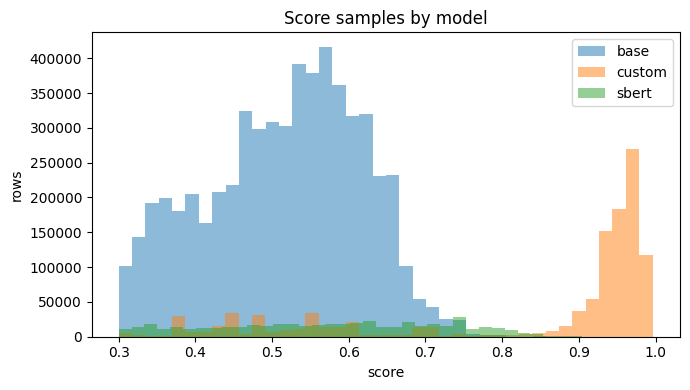

In [406]:
score_paths = inventory.loc[lambda df: df["file_type"] == "score_samples", "path"].tolist()
score_frames = []
for path in tqdm(score_paths):
    score_frames.append(pd.read_csv(path, nrows=200_000))

score_df = pd.concat(score_frames, ignore_index=True) if score_frames else pd.DataFrame()
score_df.head()

if not score_df.empty:
    plt.figure(figsize=(7, 4))
    for model, group in score_df.groupby("model"):
        group["score"].plot.hist(bins=40, alpha=0.5, label=model)
    plt.title("Score samples by model")
    plt.xlabel("score")
    plt.ylabel("rows")
    plt.legend()
    plt.tight_layout()
    plt.show()

## Comment labels (`*_all_text_comment_labels.csv`)

Match rates per comment chunk.


In [35]:
comment_paths = inventory.loc[lambda df: df["file_type"] == "comment_labels", "path"].tolist()
if not RUN_FULL_SCAN:
    comment_paths = comment_paths[:MAX_FILES_PER_TYPE]

comment_stats = []
for path in comment_paths:
    total_rows = 0
    matched_yes = 0
    total_responses = 0
    for chunk in pd.read_csv(path, usecols=["matched", "num_responses_matched"], chunksize=CHUNKSIZE):
        total_rows += len(chunk)
        matched_yes += (chunk["matched"].astype(str).str.lower() == "yes").sum()
        total_responses += chunk["num_responses_matched"].fillna(0).sum()
    comment_stats.append(
        {
            "path": path,
            "comments": total_rows,
            "matched_yes": int(matched_yes),
            "match_rate": (matched_yes / total_rows) if total_rows else 0,
            "avg_responses_per_comment": (total_responses / total_rows) if total_rows else 0,
        }
    )

comment_stats_df = pd.DataFrame(comment_stats)
comment_stats_df


,path,comments,matched_yes,match_rate,avg_responses_per_comment
0,/Users/spangher/Projects/stanford-research/rfi...,504,181,0.359127,2.876984
1,/Users/spangher/Projects/stanford-research/rfi...,36,3,0.083333,0.166667
2,/Users/spangher/Projects/stanford-research/rfi...,1079,173,0.160334,0.264133
3,/Users/spangher/Projects/stanford-research/rfi...,15,11,0.733333,2.133333
4,/Users/spangher/Projects/stanford-research/rfi...,143,104,0.727273,2.356643


## Matching pipeline log

`pipeline_log.csv` summarizes model choices and metrics from `match_comments.py`.


In [37]:
log_path = ROOT / "pipeline_log.csv"
if log_path.exists():
    log_df = pd.read_csv(log_path)
    display(log_df.head())
    display(log_df["strategy"].value_counts())
else:
    print(f"No pipeline log found at {log_path}")


,timestamp,file,file_id,total_rows,sampled_rows,labeled_rows,label_dist_yes,label_dist_no,base_f1,base_threshold,base_precision,base_recall,sbert_f1,sbert_threshold,sbert_precision,sbert_recall,custom_f1,custom_threshold,custom_precision,custom_recall,triplet_count,strategy,chosen_model,chosen_threshold,chosen_f1,match_rate,status,error
0,2026-02-17T00:35:01.227436,/scr/alexspan/regulations-demo/data/bulk_downl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,error,'response_id'
1,2026-02-17T00:55:17.517610,/scr/alexspan/regulations-demo/data/bulk_downl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,error,CUDA out of memory. Tried to allocate 96.00 Mi...
2,2026-02-17T01:02:28.194926,/scr/alexspan/regulations-demo/data/bulk_downl...,public_submission_all_text_chunked,64324.0,1000.0,1000.0,188.0,812.0,0.524675,0.530073,0.512690,0.537234,0.474501,0.612411,0.406844,0.569149,0.423256,0.953408,0.376033,0.484043,171.0,threshold_base_finetuned,base,0.530073,0.524675,0.0565,NaN,NaN
3,2026-02-17T03:13:43.549268,/scr/alexspan/regulations-demo/data/bulk_downl...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,error,'float' object is not subscriptable
4,2026-02-17T03:26:08.003606,/scr/alexspan/regulations-demo/data/bulk_downl...,public_submission_all_text_chunked,177576.0,1000.0,1000.0,108.0,892.0,0.423208,0.480359,0.335135,0.574074,0.468864,0.685227,0.387879,0.592593,0.356688,0.961906,0.271845,0.518519,106.0,threshold_sbert_finetuned,sbert,0.685227,0.468864,0.1096,NaN,NaN


strategy
threshold_base_finetuned      44
threshold_sbert_finetuned     36
llm_direct                    31
threshold_base_fallback        8
threshold_sbert_fallback       5
threshold_custom_finetuned     5
threshold_sbert                2
threshold_base                 1
Name: count, dtype: int64